# DHO1000 Rigol Waveform Examples

**awiamo**

*light editing by Scott Prahl for new API*

**March 2026**

This notebook demonstrates extracting signals from `.wfm` and `.bin` files created by Rigol DHO800/DHO1000 series oscilloscopes.

The Rigol DHO series supports two waveform export formats:

* **`.bin`** - Official binary format documented in the DHO1000 User Guide §19.2.4. Contains calibrated float32 voltage samples for each enabled channel.
* **`.wfm`** - Proprietary format containing zlib-compressed metadata blocks followed by raw uint16 ADC samples (reverse-engineered).  This has much more scope information than the `.bin` format.

In [1]:
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio

from RigolWFM import Wfm, DHO1000_scopes

repo = "https://github.com/scottprahl/RigolWFM/raw/main/tests/files/"

A list of Rigol scopes in the DHO1000 family is:

In [2]:
print(DHO1000_scopes)

['DHO', 'DHO800', 'DHO1000', 'DHO804', 'DHO812', 'DHO814', 'DHO824', 'DHO1072', 'DHO1074', 'DHO1102', 'DHO1202', 'DHO1204']


## DHO1074 - Single-channel `.wfm` capture



### Look at a screen shot



This capture was taken on a DHO1074 oscilloscope with CH1 active, measuring a 3.3 V logic signal.



<img src="https://github.com/scottprahl/RigolWFM/raw/main/tests/files/wfm/DHO1074.png" width="60%">



### Import the `.wfm` data

In [3]:
filename = "wfm/DHO1074.wfm"

w = Wfm.from_url(repo + filename, "DHO")

downloading 'https://github.com/scottprahl/RigolWFM/raw/main/tests/files/wfm/DHO1074.wfm'


### Textual description of the waveform

In [4]:
description = w.describe()
print(description)

    General:
        File Model   = DHO1000
        User Model   = DHO
        Parser Model = dho1000
        Firmware     = unknown
        Filename     = DHO1074.wfm
        Channels     = [1, 2, 3, 4]

    Trigger:
        Derived Level (CH1) = -919.98 mV
        Derived Level (CH2) = -3.34  V
        Derived Level (CH3) = 2.95  V
        Derived Level (CH4) = 29.00  V

     Channel 1:
         Coupling =  unknown
            Scale =    54.61  V/div
           Offset =   154.00  V
            Probe =       1X
         Inverted =    False

        Time Base =    5.000 ms/div
           Offset =    0.000  s
            Delta =    5.000 µs/point
           Points =    10000

         Count    = [        1,        2,        3  ...      9999,    10000]
           Raw    = [      207,      207,      208  ...       207,      207]
           Times  = [-25.000 ms,-24.995 ms,-24.990 ms  ... 24.990 ms,24.995 ms]
           Volts  = [-17.81  V,-18.49  V,-16.47  V  ... -18.59  V,-18.93  V]

    

### Plot the waveform

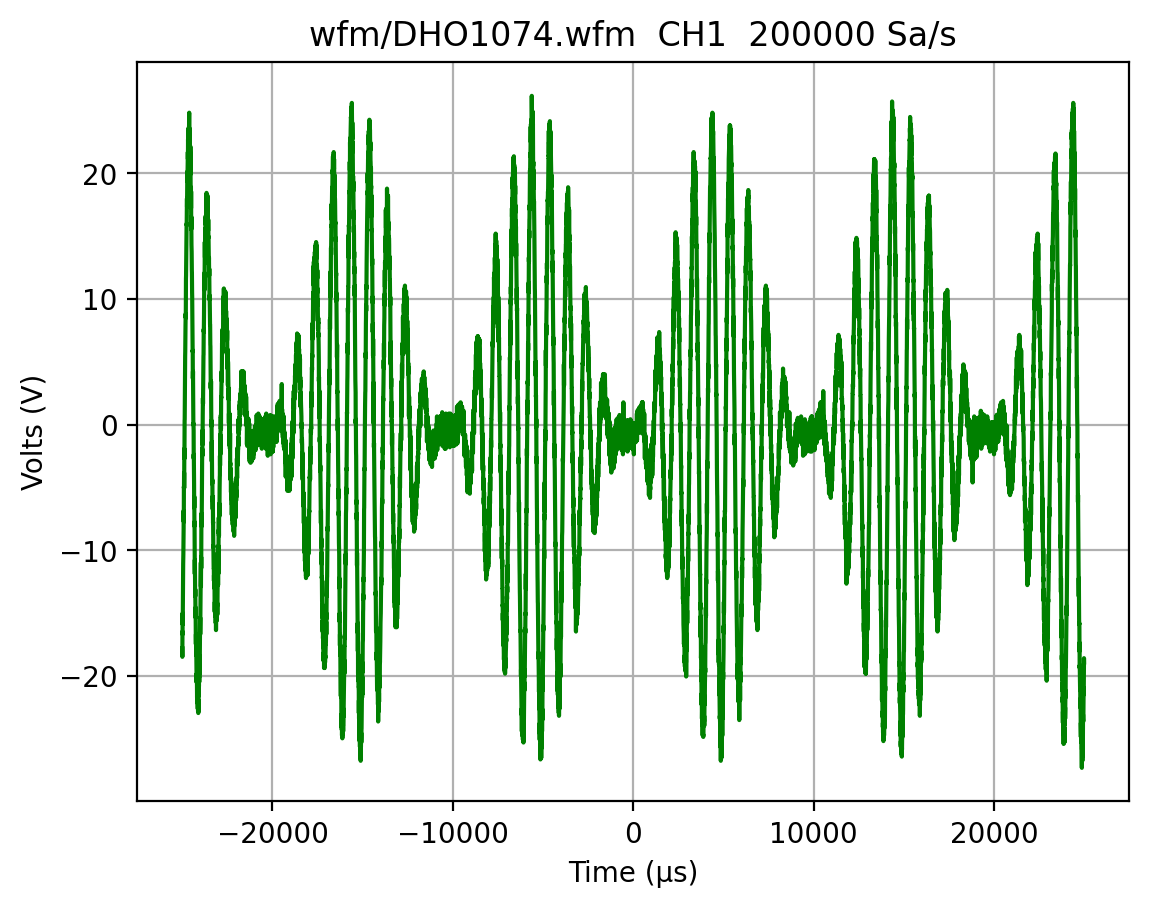

In [5]:
ch = w.channels[0]

plt.plot(ch.times * 1e6, ch.volts, color="green")
plt.title("%s  CH%d  %.0f Sa/s" % (filename, ch.channel_number, 1 / ch.seconds_per_point))
plt.xlabel("Time (µs)")
plt.ylabel("Volts (V)")
plt.grid(True)

plt.show()

The `w.plot()` convenience method draws all enabled channels automatically:

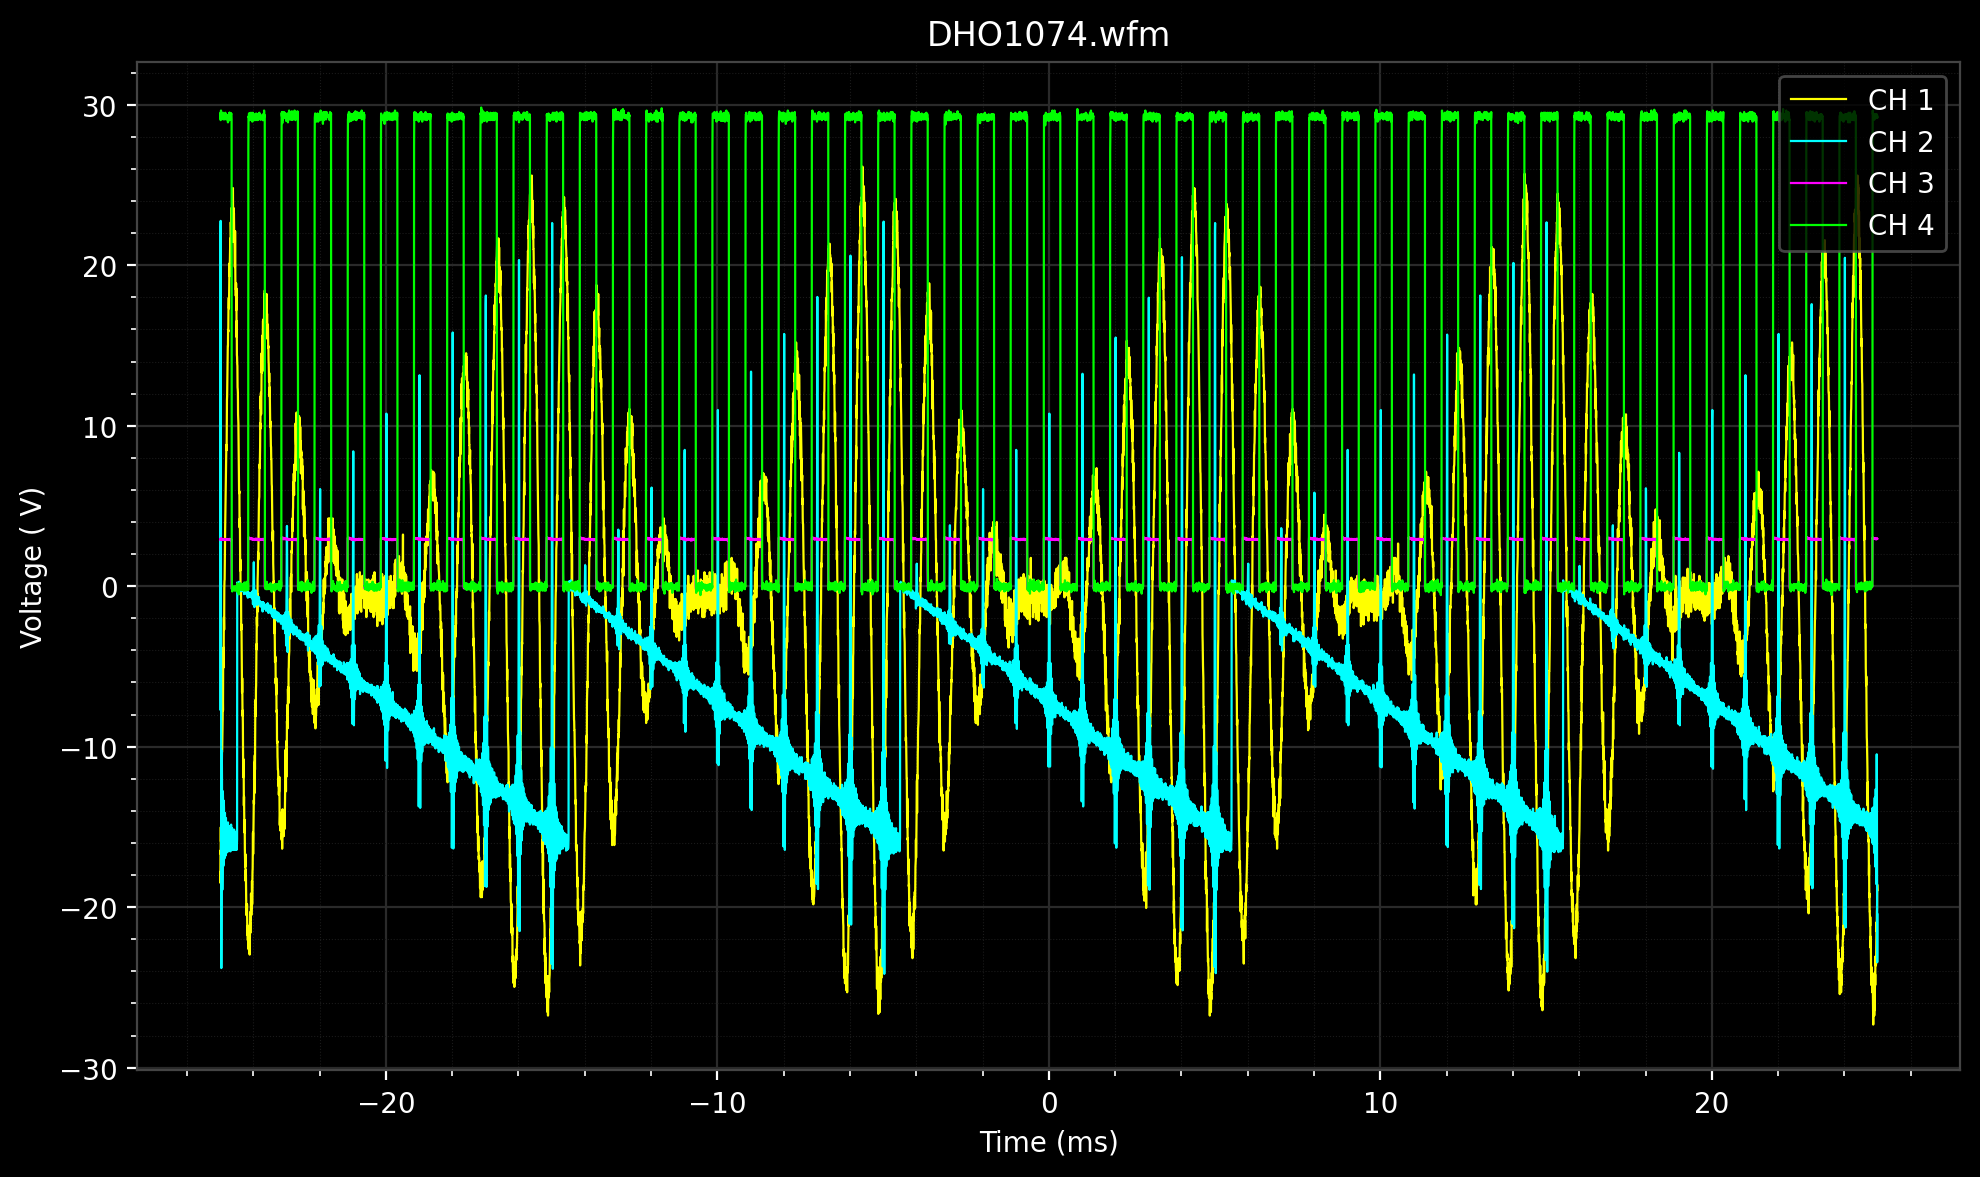

In [6]:
w.plot()
plt.show()

## DHO1074 - Four-channel `.bin` capture

### Look at a screen shot

This capture was taken on a DHO1074 oscilloscope with all four channels enabled.
The `.bin` format is documented in the DHO1000 User Guide, Section 19.2.4.
It stores calibrated float32 voltage values directly - no additional scaling is required.

<img src="https://github.com/scottprahl/RigolWFM/raw/main/tests/files/wfm/DHO1074.png" width="60%">

### Import the `.bin` data

In [7]:
filename = "bin/DHO1074.bin"
w = Wfm.from_url(repo + filename)

downloading 'https://github.com/scottprahl/RigolWFM/raw/main/tests/files/bin/DHO1074.bin'


### Textual description of the waveform

In [8]:
description = w.describe()
print(description)

    General:
        File Model   = DHO1000 (BIN)
        User Model   = auto
        Parser Model = dho1000
        Firmware     = unknown
        Filename     = DHO1074.bin
        Channels     = [1, 2, 3, 4]

    Trigger:
        Derived Level (CH1) = -913.33 mV
        Derived Level (CH2) = -3.34  V
        Derived Level (CH3) = 2.95  V
        Derived Level (CH4) = 28.99  V

     Channel 1:
         Coupling =  unknown
            Scale =     1.00  V/div
           Offset =     0.00  V
            Probe =       1X
         Inverted =    False

        Time Base =    5.000 ms/div
           Offset =    0.000  s
            Delta =    5.000 µs/point
           Points =    10000

         Count    = [        1,        2,        3  ...      9999,    10000]
           Raw    = [       58,       55,       63  ...        55,       54]
           Times  = [-25.000 ms,-24.995 ms,-24.990 ms  ... 24.990 ms,24.995 ms]
           Volts  = [-17.81  V,-18.48  V,-16.47  V  ... -18.59  V,-18.93  V

### Plot all four channels

The `.bin` format stores each channel independently. All four are plotted below.

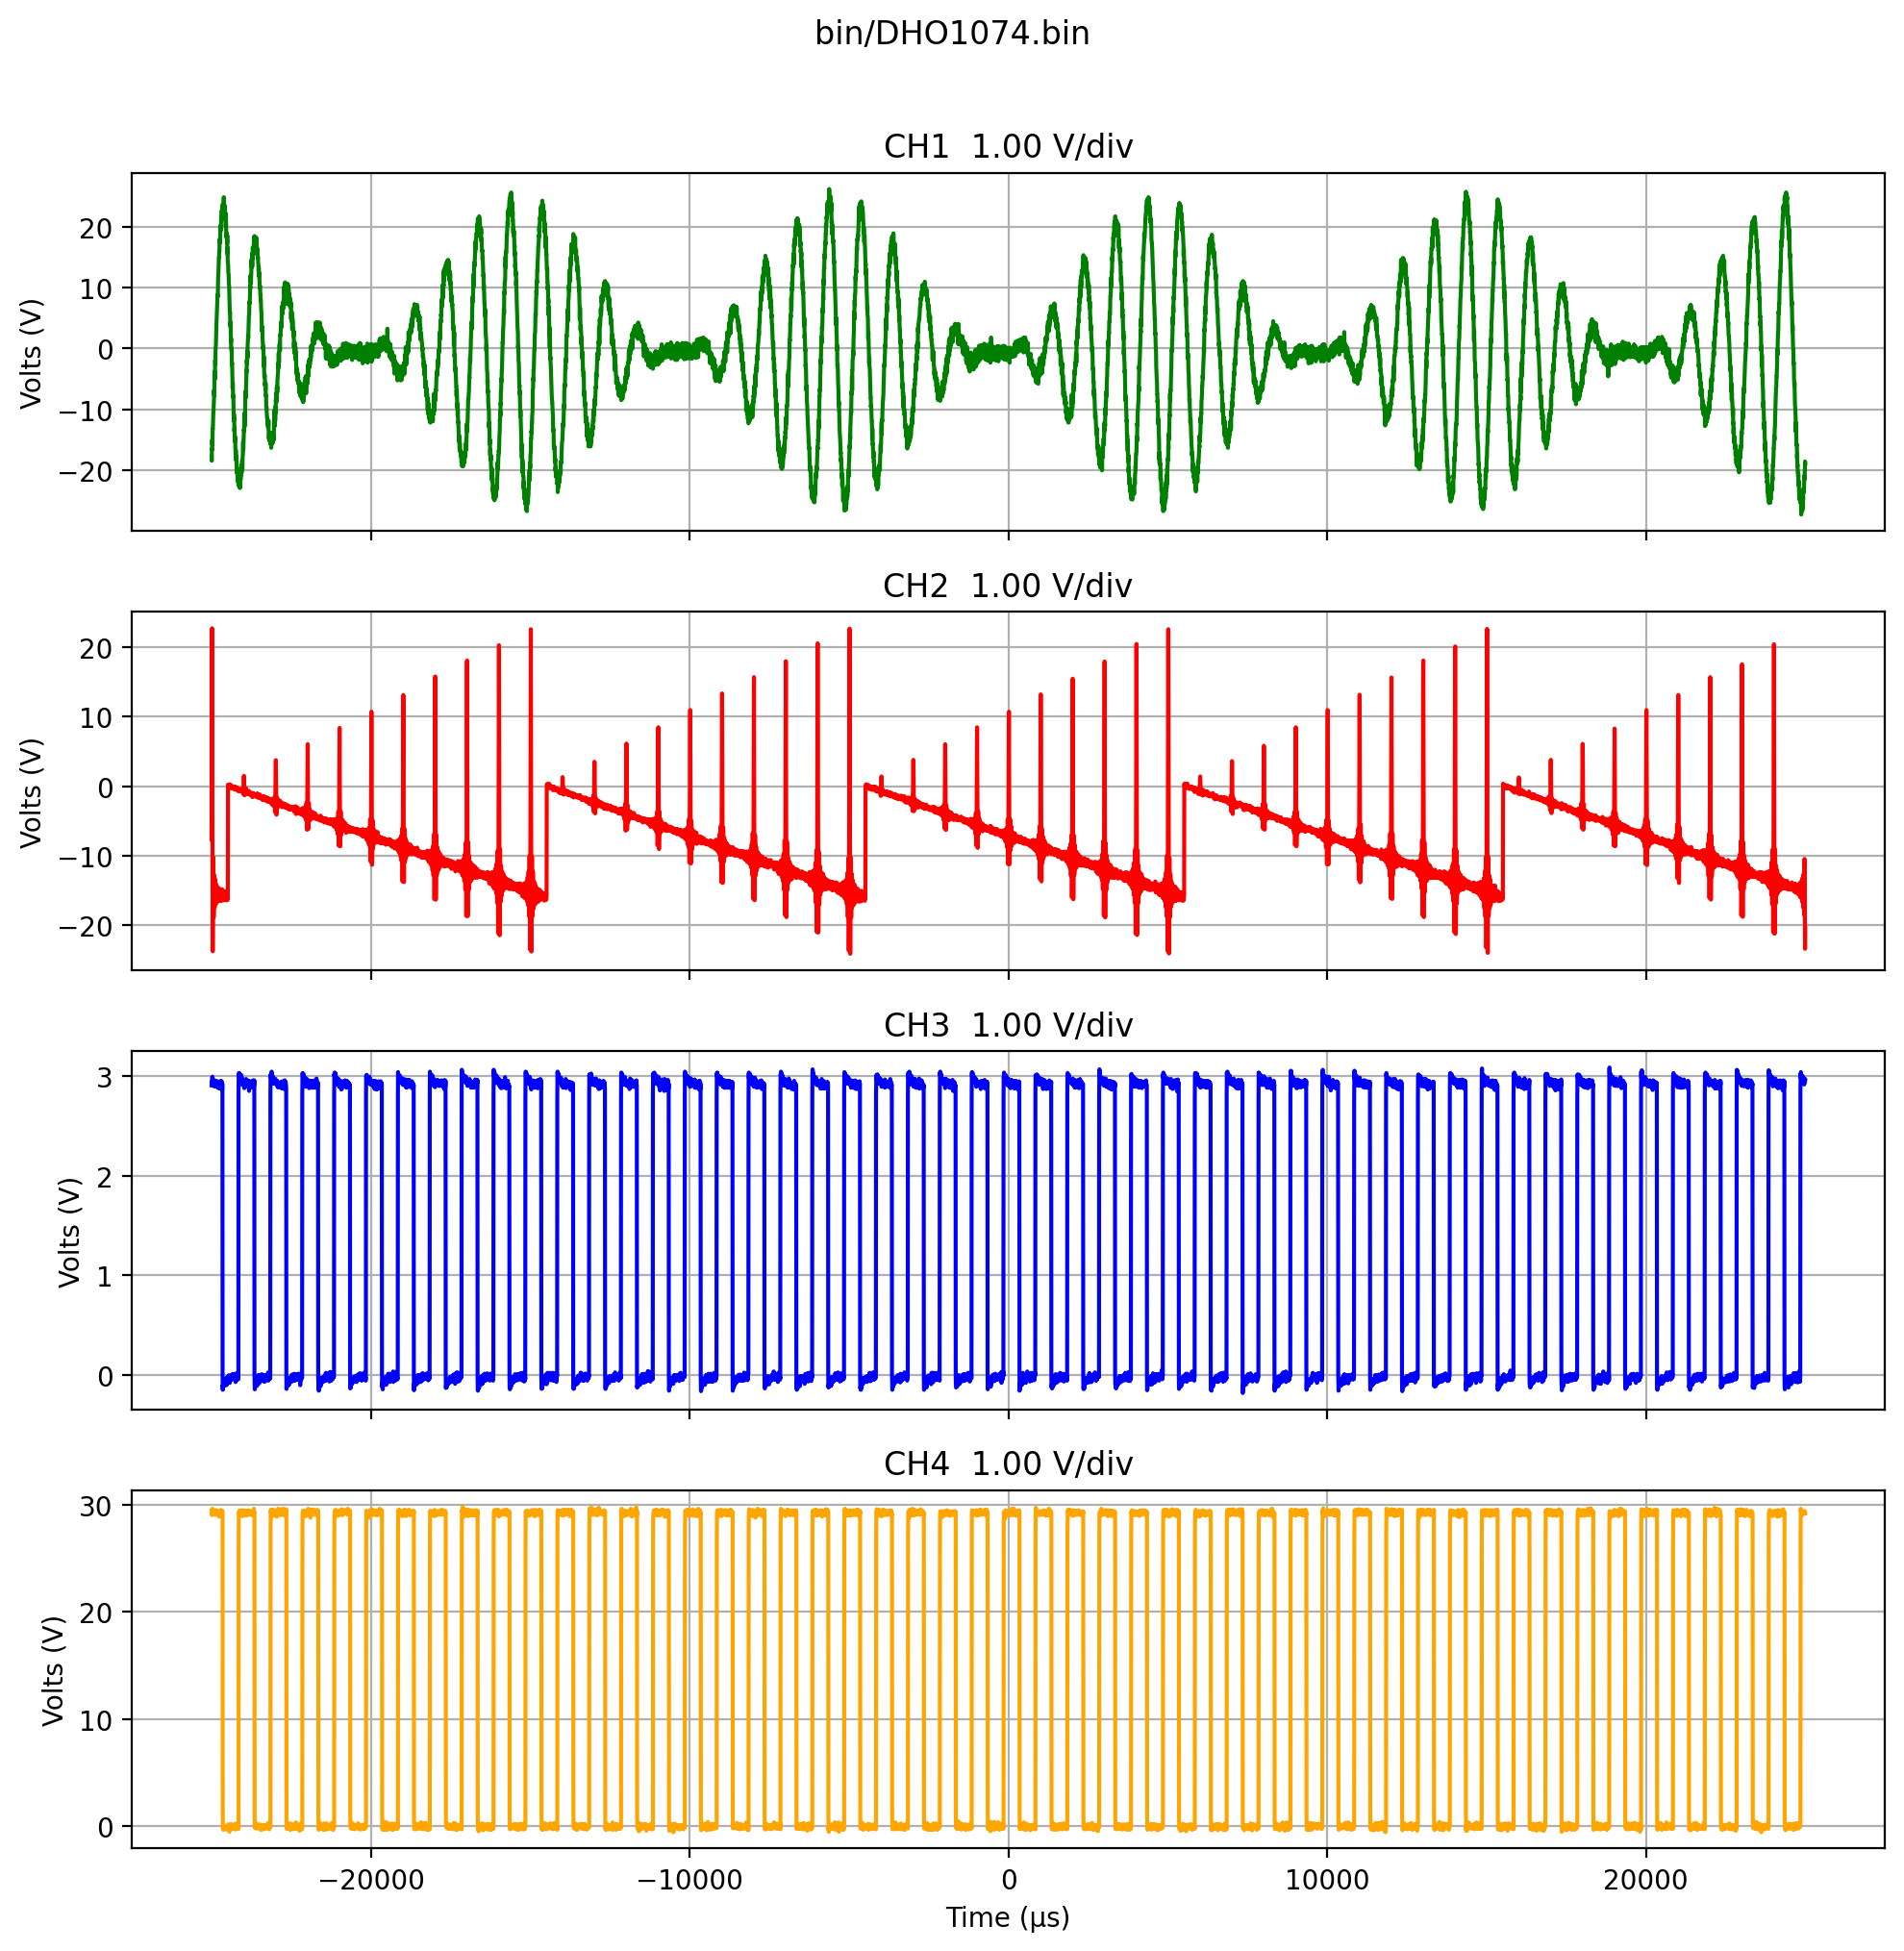

In [9]:
colors = ["green", "red", "blue", "orange"]
active = [ch for ch in w.channels if ch.volts is not None]
n = len(active)

fig, axes = plt.subplots(n, 1, sharex=True, figsize=(10, 2.5 * n))
if n == 1:
    axes = [axes]

for ax, ch, color in zip(axes, active, colors):
    ax.plot(ch.times * 1e6, ch.volts, color=color)
    ax.set_ylabel("Volts (V)")
    ax.set_title("CH%d  %.2f V/div" % (ch.channel_number, ch.volt_per_division))
    ax.grid(True)

axes[-1].set_xlabel("Time (µs)")
fig.suptitle(filename, y=1.01)
plt.tight_layout()
plt.show()

The `w.plot()` convenience method draws the same result in a single call:

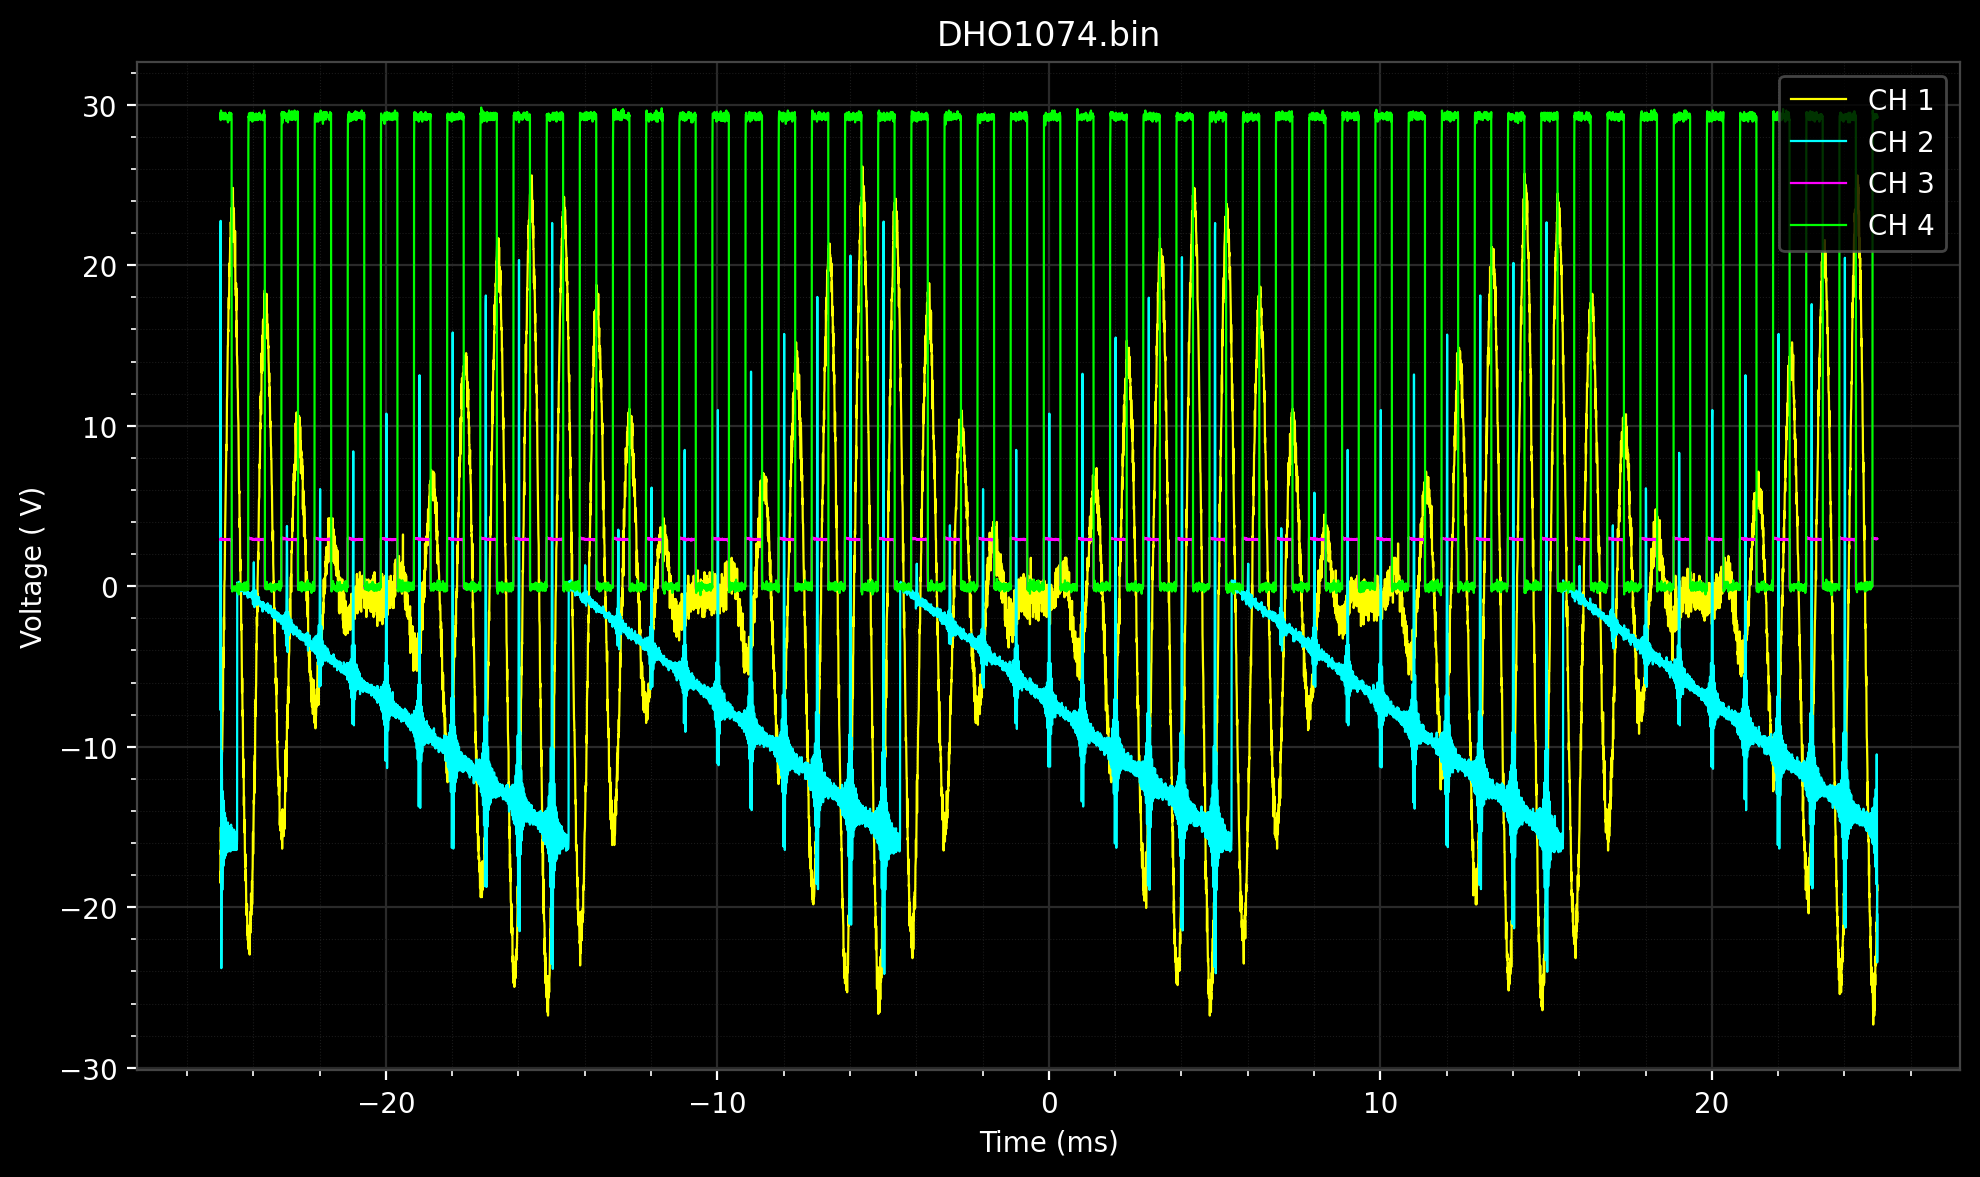

In [10]:
w.plot()
plt.show()

### Select a single channel from a multi-channel `.bin` file

Pass the `selected` argument to `Wfm.from_file()` to load only specific channels.
This avoids allocating memory for channels you do not need.

downloading 'https://github.com/scottprahl/RigolWFM/raw/main/tests/files/bin/DHO1074.bin'


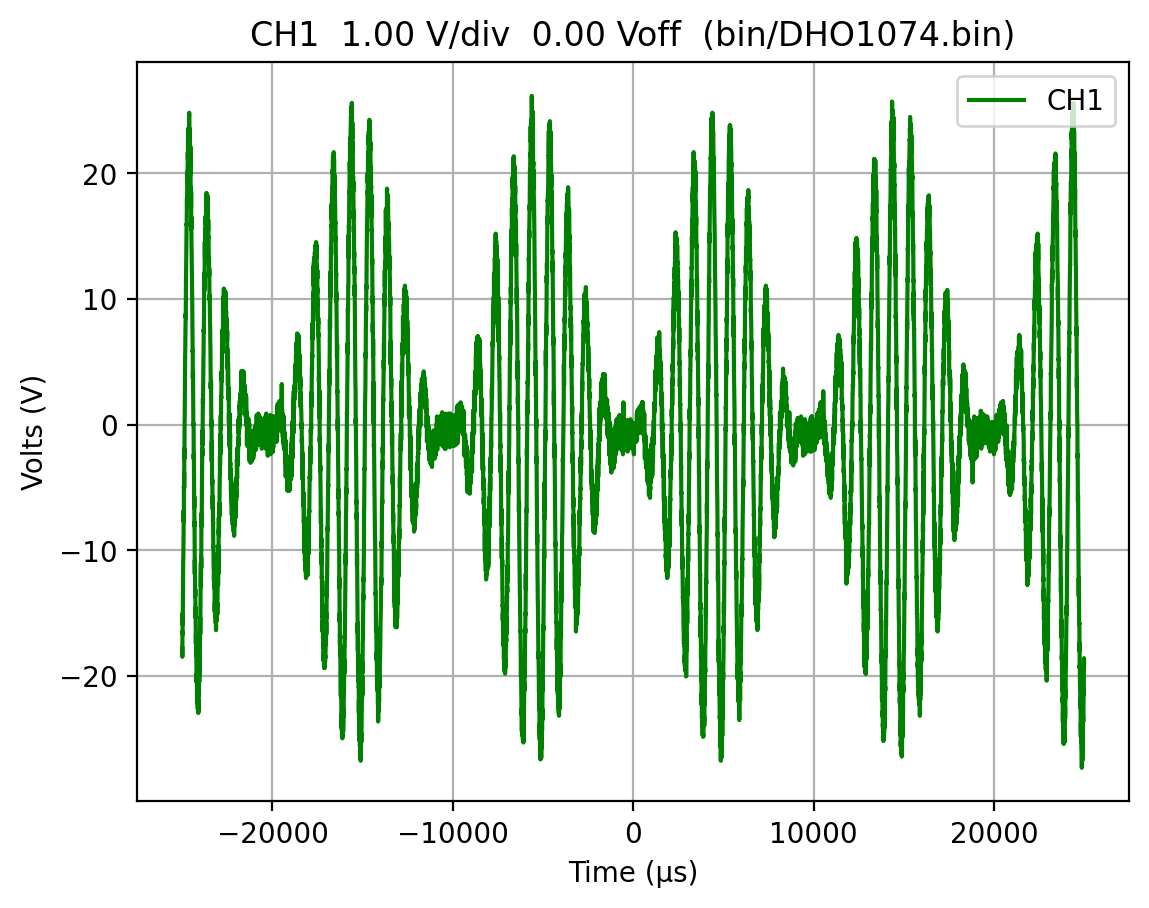

In [11]:
filename = "bin/DHO1074.bin"
w1 = Wfm.from_url(repo + filename, selected="1")

ch = w1.channels[0]
plt.title("CH%d  %.2f V/div  %.2f Voff  (%s)" % (ch.channel_number, ch.volt_per_division, ch.volt_offset, filename))
plt.plot(ch.times * 1e6, ch.volts, color="green", label="CH1")
plt.xlabel("Time (µs)")
plt.ylabel("Volts (V)")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

## Format comparison: `.wfm` vs `.bin`



DHO1074.wfm and DHO1074.bin are captures from the same oscilloscope model (DHO1074)

but from different measurement sessions, so a direct sample-by-sample comparison is

not meaningful here.  The table below summarises the key differences between the two formats.



| Property | `.bin` | `.wfm` |
|---|---|---|
| Documented | Yes (User Guide §19.2.4) | No (reverse-engineered) |
| Sample type | float32 (calibrated V) | uint16 (raw ADC) |
| Channels | All enabled, separate | CH1 only in tested files |
| Metadata | In waveform headers | zlib-compressed blocks |
| x_origin sign | Positive (negate for t0) | Negative (use directly) |

In [12]:
wfm = Wfm.from_url(repo + "wfm/DHO1074.wfm", "DHO")

wfm_ch = wfm.channels[0]


print("DHO1074.wfm")

print("  Points     : %d" % len(wfm_ch.times))

print("  Delta t    : %.3f µs" % (wfm_ch.seconds_per_point * 1e6))

print("  Time span  : %.3f ms" % ((wfm_ch.times[-1] - wfm_ch.times[0]) * 1e3))

print("  Vmin / Vmax: %.3f V / %.3f V" % (wfm_ch.volts.min(), wfm_ch.volts.max()))

print()


bin_ = Wfm.from_url(repo + "bin/DHO1074.bin", selected="1")

bin_ch = bin_.channels[0]


print("DHO1074.bin  (CH1 only)")

print("  Points     : %d" % len(bin_ch.times))

print("  Delta t    : %.3f µs" % (bin_ch.seconds_per_point * 1e6))

print("  Time span  : %.3f ms" % ((bin_ch.times[-1] - bin_ch.times[0]) * 1e3))

print("  Vmin / Vmax: %.3f V / %.3f V" % (bin_ch.volts.min(), bin_ch.volts.max()))

downloading 'https://github.com/scottprahl/RigolWFM/raw/main/tests/files/wfm/DHO1074.wfm'


DHO1074.wfm
  Points     : 10000
  Delta t    : 5.000 µs
  Time span  : 49.995 ms
  Vmin / Vmax: -27.320 V / 26.153 V

DHO1074.bin  (CH1 only)
  Points     : 10000
  Delta t    : 5.000 µs
  Time span  : 49.995 ms
  Vmin / Vmax: -27.313 V / 26.160 V


downloading 'https://github.com/scottprahl/RigolWFM/raw/main/tests/files/bin/DHO1074.bin'
